# Análise de Dados e Insights - E-commerce




In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data/ecommerce_pedidos_limpo.csv')
df.head()

,pedido_id,cliente,estado,produto,categoria,quantidade,valor_unitario,valor_total,status,pagamento,data_pedido,data_entrega,valor_total_original,dias_entrega,mes,ano,pedido_valido
0,1,Diego Souza,RJ,Mochila Samsonite,Acessórios,3,259.9,779.7,Entregue,Cartão de Débito,2024-11-27,NaN,779.7,NaN,11.0,2024.0,True
1,2,Lucas Pereira,GO,Mochila Samsonite,Acessórios,2,259.9,519.8,Entregue,Boleto,2024-10-14,NaN,519.8,NaN,10.0,2024.0,True
2,3,Marina Gomes,PE,Calça Jeans Levi's,Vestuário,3,199.9,599.7,Cancelado,Cartão de Débito,2024-03-17,NaN,599.7,NaN,3.0,2024.0,False
3,4,Henrique Alves,PE,Smartwatch Samsung,Eletrônicos,5,899.0,4495.0,Cancelado,Boleto,2024-07-09,NaN,4495.0,NaN,7.0,2024.0,False
4,5,João Oliveira,RJ,Tênis Nike Air Max,Calçados,4,349.9,1399.6,Cancelado,Boleto,2024-05-13,NaN,1399.6,NaN,5.0,2024.0,False


## 1. Preparando a base para análise

In [3]:
df['data_pedido'] = pd.to_datetime(df['data_pedido'], errors='coerce')
df['data_entrega'] = pd.to_datetime(df['data_entrega'], errors='coerce')

validos = df[df['status'] != 'Cancelado']
entregues = df[df['status'] == 'Entregue']

## 2. KPIs principais


- **Faturamento bruto:** todos os pedidos da base.
- **Faturamento líquido:** pedidos que não foram cancelados.
- **Faturamento entregue:** apenas pedidos com status `Entregue`.

In [ ]:
pedidos_totais = df['pedido_id'].count()
pedidos_validos = validos['pedido_id'].count()
pedidos_entregues = entregues['pedido_id'].count()
pedidos_cancelados = df[df['status'] == 'Cancelado']['pedido_id'].count()

faturamento_bruto = df['valor_total'].sum()
faturamento_liquido = validos['valor_total'].sum()
faturamento_entregue = entregues['valor_total'].sum()

ticket_medio_liquido = faturamento_liquido / pedidos_validos
itens_vendidos = validos['quantidade'].sum()

taxa_cancelamento = pedidos_cancelados / pedidos_totais * 100
taxa_entrega = pedidos_entregues / pedidos_totais * 100
prazo_medio_entrega = entregues['dias_entrega'].mean()

print('Pedidos totais:', pedidos_totais)
print('Pedidos válidos:', pedidos_validos)
print('Pedidos entregues:', pedidos_entregues)
print('Pedidos cancelados:', pedidos_cancelados)
print('Faturamento bruto: R$', round(faturamento_bruto, 2))
print('Faturamento líquido: R$', round(faturamento_liquido, 2))
print('Faturamento entregue: R$', round(faturamento_entregue, 2))
print('Ticket médio líquido: R$', round(ticket_medio_liquido, 2))
print('Itens vendidos:', itens_vendidos)
print('Taxa de cancelamento:', round(taxa_cancelamento, 2), '%')
print('Taxa de entrega:', round(taxa_entrega, 2), '%')
print('Prazo médio de entrega:', round(prazo_medio_entrega, 2), 'dias')

## 3. Faturamento por mês

In [5]:
faturamento_mes = validos.groupby('mes')['valor_total'].sum()
faturamento_mes

mes
1.0      67393.8
2.0      82615.9
3.0      71869.9
4.0      57515.6
5.0      71219.3
6.0      46791.1
7.0      70330.8
8.0     102569.9
9.0      60266.7
10.0     58103.2
11.0     91231.7
12.0     50135.1
Name: valor_total, dtype: float64

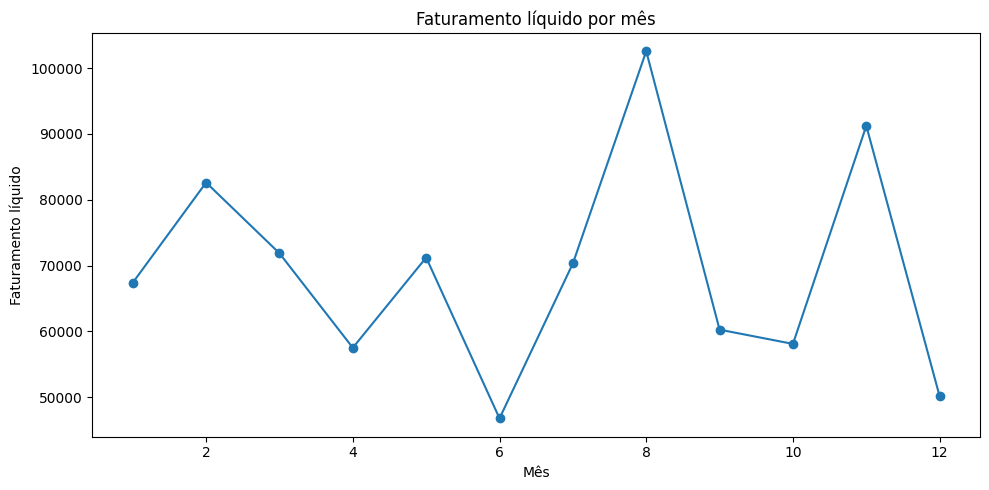

In [6]:
plt.figure(figsize=(10, 5))
faturamento_mes.plot(kind='line', marker='o')
plt.title('Faturamento líquido por mês')
plt.xlabel('Mês')
plt.ylabel('Faturamento líquido')
plt.tight_layout()
plt.savefig('grafico/grafico_faturamento_mensal.png')
plt.show()

## 4. Faturamento por categoria

In [7]:
faturamento_categoria = validos.groupby('categoria')['valor_total'].sum().sort_values(ascending=False)
faturamento_categoria

categoria
Eletrônicos    622507.3
Acessórios     104972.5
Calçados        68507.9
Vestuário       40003.0
Name: valor_total, dtype: float64

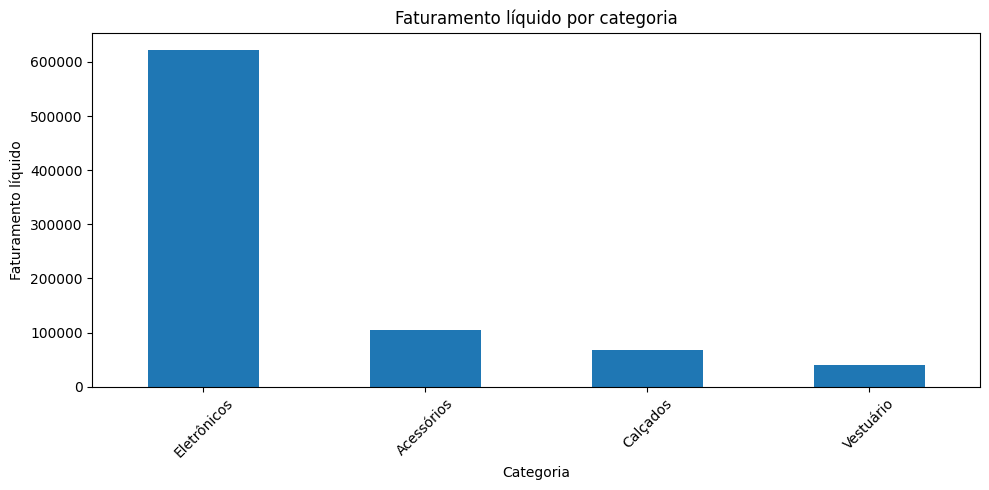

In [8]:
plt.figure(figsize=(10, 5))
faturamento_categoria.plot(kind='bar')
plt.title('Faturamento líquido por categoria')
plt.xlabel('Categoria')
plt.ylabel('Faturamento líquido')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('grafico/grafico_faturamento_categoria.png')
plt.show()

## 5. Produto com maior faturamento

In [9]:
faturamento_produto = validos.groupby('produto')['valor_total'].sum().sort_values(ascending=False)
faturamento_produto.head(10)

produto
Notebook Dell         471757.0
Smartwatch Samsung    121365.0
Óculos Ray-Ban         43640.3
Tênis Vans             35267.4
Tênis Nike Air Max     33240.5
Mochila Samsonite      31707.8
Relógio Casio          29624.4
Fone JBL Bluetooth     29385.3
Calça Jeans Levi's     28585.7
Camiseta Adidas        11417.3
Name: valor_total, dtype: float64

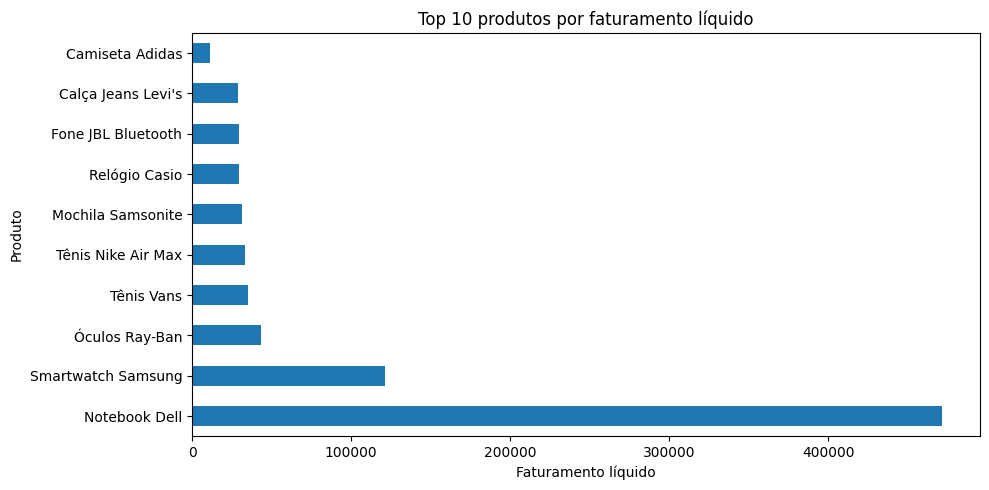

In [10]:
plt.figure(figsize=(10, 5))
faturamento_produto.head(10).plot(kind='barh')
plt.title('Top 10 produtos por faturamento líquido')
plt.xlabel('Faturamento líquido')
plt.ylabel('Produto')
plt.tight_layout()
plt.savefig('grafico/grafico_top_produtos.png')
plt.show()

## 6. Forma de pagamento

In [11]:
pedidos_pagamento = validos['pagamento'].value_counts()
pedidos_pagamento

pagamento
Cartão de Débito     110
PIX                  110
Boleto               107
Cartão de Crédito     97
Não informado          7
Name: count, dtype: int64

In [12]:
faturamento_pagamento = validos.groupby('pagamento')['valor_total'].sum().sort_values(ascending=False)
faturamento_pagamento

pagamento
Cartão de Débito     245282.0
Cartão de Crédito    220524.1
PIX                  197921.3
Boleto               164808.0
Não informado          7455.3
Name: valor_total, dtype: float64

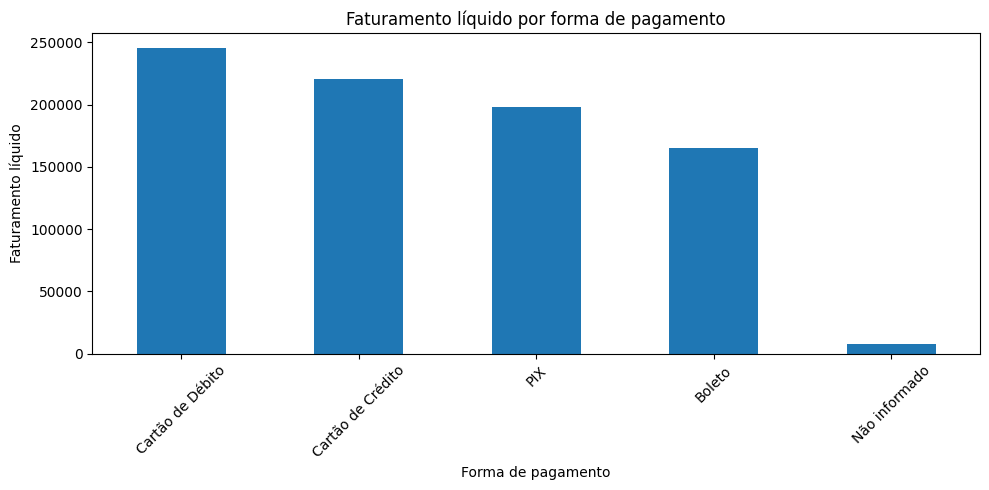

In [13]:
plt.figure(figsize=(10, 5))
faturamento_pagamento.plot(kind='bar')
plt.title('Faturamento líquido por forma de pagamento')
plt.xlabel('Forma de pagamento')
plt.ylabel('Faturamento líquido')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('grafico/grafico_pagamento.png')
plt.show()

## 7. Quantidade de pedidos por estado

In [14]:
pedidos_estado = validos.groupby('estado')['pedido_id'].count().sort_values(ascending=False)
pedidos_estado

estado
PE               50
GO               48
BA               45
SC               44
MG               41
CE               40
PR               40
RS               40
RJ               39
SP               39
Não informado     5
Name: pedido_id, dtype: int64

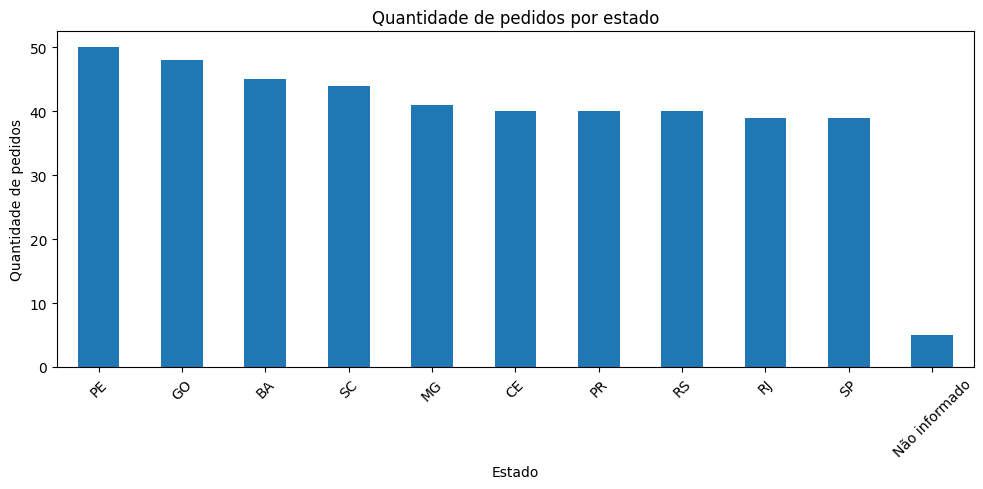

In [15]:
plt.figure(figsize=(10, 5))
pedidos_estado.plot(kind='bar')
plt.title('Quantidade de pedidos por estado')
plt.xlabel('Estado')
plt.ylabel('Quantidade de pedidos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('grafico/grafico_pedidos_por_estado.png')
plt.show()

## 8. Quantidade vendida por estado



In [16]:
quantidade_vendida_estado = validos.groupby('estado')['quantidade'].sum().sort_values(ascending=False)
quantidade_vendida_estado

estado
PE               162
SC               144
RS               137
MG               132
GO               128
PR               123
BA               120
SP               116
CE               111
RJ               109
Não informado      9
Name: quantidade, dtype: int64

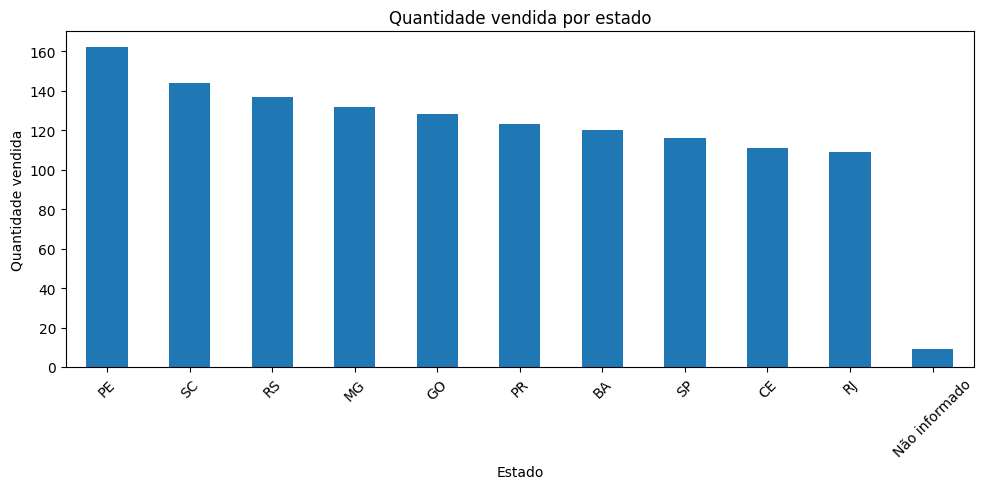

In [17]:
plt.figure(figsize=(10, 5))
quantidade_vendida_estado.plot(kind='bar')
plt.title('Quantidade vendida por estado')
plt.xlabel('Estado')
plt.ylabel('Quantidade vendida')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('grafico/grafico_quantidade_vendida_estado.png')
plt.show()

# 9. Faturamento por Estado


In [ ]:
faturamento_estado = validos.groupby("estado")["valor_total"].sum().sort_values(ascending=False)
print(faturamento_estado)

In [ ]:
plt.figure(figsize=(10, 5))
faturamento_estado.plot(kind='bar')
plt.title('Faturamento por Estado')
plt.xlabel('Estado')
plt.ylabel('Faturamento (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('grafico/faturamento_por_estado.png')
plt.show()

## 9. Status dos pedidos

In [18]:
status_pedidos = df['status'].value_counts()
status_pedidos

status
Entregue       304
Cancelado       79
Em trânsito     67
Pendente        60
Name: count, dtype: int64

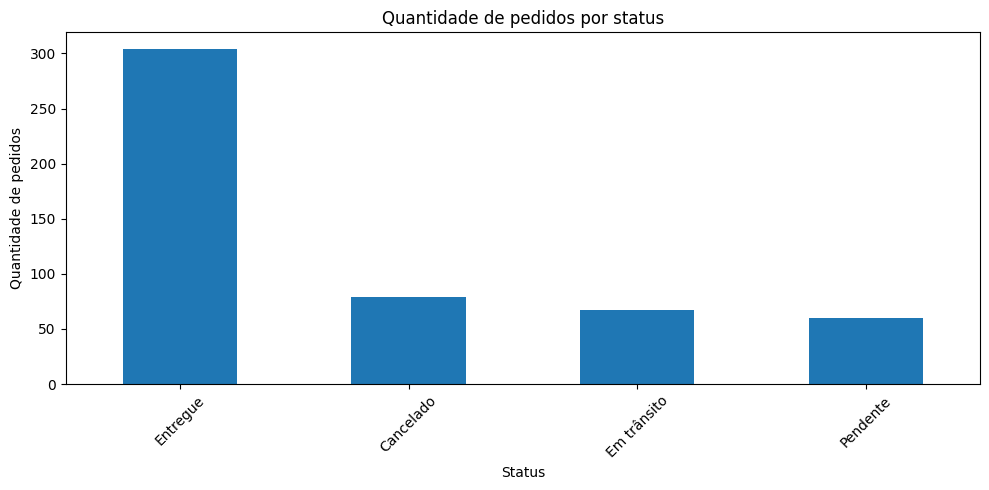

In [19]:
plt.figure(figsize=(10, 5))
status_pedidos.plot(kind='bar')
plt.title('Quantidade de pedidos por status')
plt.xlabel('Status')
plt.ylabel('Quantidade de pedidos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('grafico/grafico_status_pedidos.png')
plt.show()

## 10. Insights finais

1. A análise principal de faturamento deve usar o **faturamento líquido**, ou seja, pedidos que não foram cancelados.
2. O produto com maior faturamento é o **Notebook Dell**, mostrando forte dependência de um produto de maior valor.
3. A categoria **Eletrônicos** concentra a maior parte do faturamento.
4. A análise por estado pode ser feita de duas formas: por quantidade de pedidos ou por quantidade vendida. Para quantidade vendida, o correto é somar a coluna `quantidade`.